TODO: 
- Аугментация (скользящим окном)
- Подбор гиперпараметров для мамбы и мамбы2
- Изменение архитектуры (например, CNN после или перед мамбой)

In [1]:
import torch
import wfdb
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

# Данные
Избавление от шума не улучшает работу модели

In [5]:
from pathlib import Path

CHANNEL_MAPPING = {
    "i": 0,
    "ii": 1,
    "iii": 2,
    "avr": 3,
    "avl": 4,
    "avf": 5,
    "v1": 6,
    "v2": 7,
    "v3": 8,
    "v4": 9,
    "v5": 10,
    "v6": 11
}


def load_wfdb_dataset(dataset_path, channel_names=['ii'], annotation_ext=['atr']):
    """
    Загружает WFDB-записи и соответствующие аннотации из указанной директории.

    Функция ищет все файлы заголовков `.hea`, считывает для каждой записи
    выбранные каналы ЭКГ и наборы аннотаций с указанными расширениями.

    :param dataset_path: Путь к папке с WFDB-записями.
    :param channel_names: Список названий каналов, которые нужно загрузить.
    :param annotation_ext: Список расширений файлов аннотаций для чтения.
    :return: Кортеж `(records, annotations)`, где `records` — список записей WFDB,
        а `annotations` — список словарей с аннотациями для каждой записи.
    """

    channels = [CHANNEL_MAPPING[i] for i in channel_names]
    
    dataset_path = Path(dataset_path)
    
    hea_files = sorted(dataset_path.glob("*.hea"))

    records = []
    annotations = []
    for hea_path in hea_files:
        # Получаем путь к записи без расширения (нужно для wfdb)
        record_base_path = str(hea_path.with_suffix(''))

        record = wfdb.rdrecord(record_base_path, channels=channels)
        print(record.comments)
        records.append(record)

        curr_rec_annotaiton = {}
        for c in annotation_ext:
            annotation = wfdb.rdann(record_base_path, c)
            curr_rec_annotaiton[c] = annotation

        annotations.append(curr_rec_annotaiton)
            
    return records, annotations

['69 M 1085 1629 x1', 'Aldomet, Inderal']
['75 F 1011 654 x1', 'Diapres']
['84 F 1525 167 x1', 'Digoxin', 'The rhythm is paced with a demand pacemaker.  The PVCs are multiform.']
['-1 M 742 654 x1', 'Diapres, Xyloprim']
['66 F 1567 694 x1', 'Digoxin, Pronestyl', 'The rate of paced rhythm is close to that of the underlying sinus rhythm,', 'resulting in many pacemaker fusion beats.  The PVCs are multiform.  Several', 'bursts of muscle noise occur, but the signals are generally of good quality.']
['73 F 1624 1629 x1', 'Digoxin, Nitropaste, Pronestyl', 'The PVCs are uniform.  The predominant feature of this tape is', 'high-grade noise and artifact.']
['24 F 1581 654 x1', 'Inderal', 'The PVCs are multiform.']
['63 M 1340 167 x1', 'Digoxin', 'Complete heart block is present. The PVCs are multiform.']
['87 F 1227 654 x1', 'Digoxin, Quinaglute', 'There is borderline first degree AV block and sinus arrhythmia.  The', 'PVCs are multiform.  The lower channel exhibits considerable noise and', 'bas

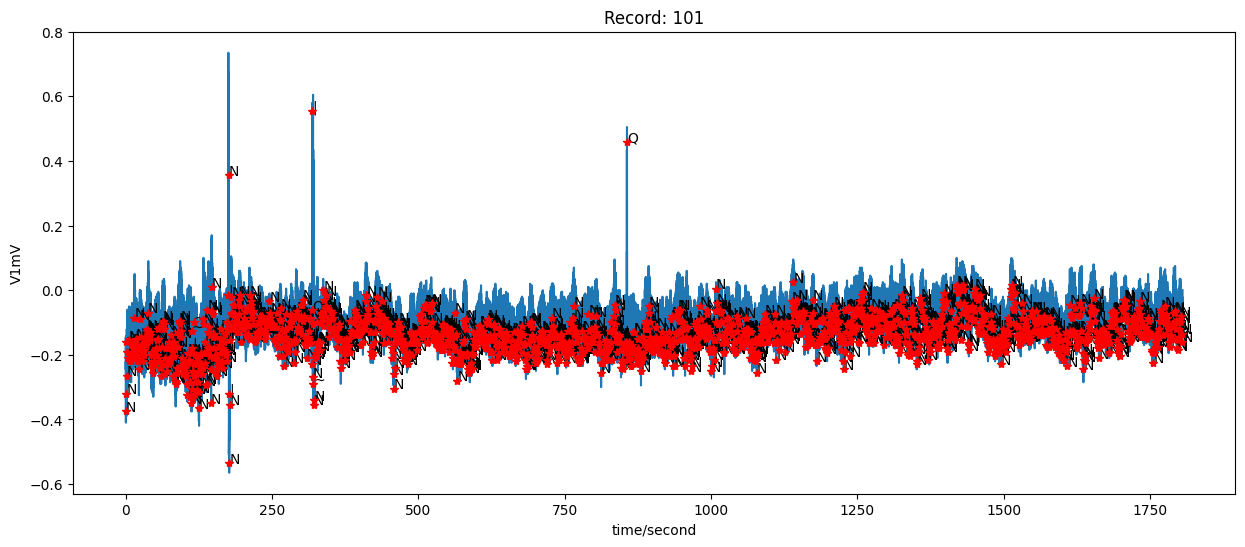

In [6]:
records, annotations = load_wfdb_dataset("physionet.org/files/mitdb/1.0.0/")

idx = 1
wfdb.plot_wfdb(record=records[idx], annotation=annotations[idx]['atr'], figsize=(15,6), plot_sym=True)

In [4]:
signals = np.array([r.p_signal for r in records])
signals.shape

(48, 650000, 1)

In [5]:
signals = signals.squeeze(2)
signals.shape

(48, 650000)

NameError: name 'signals' is not defined

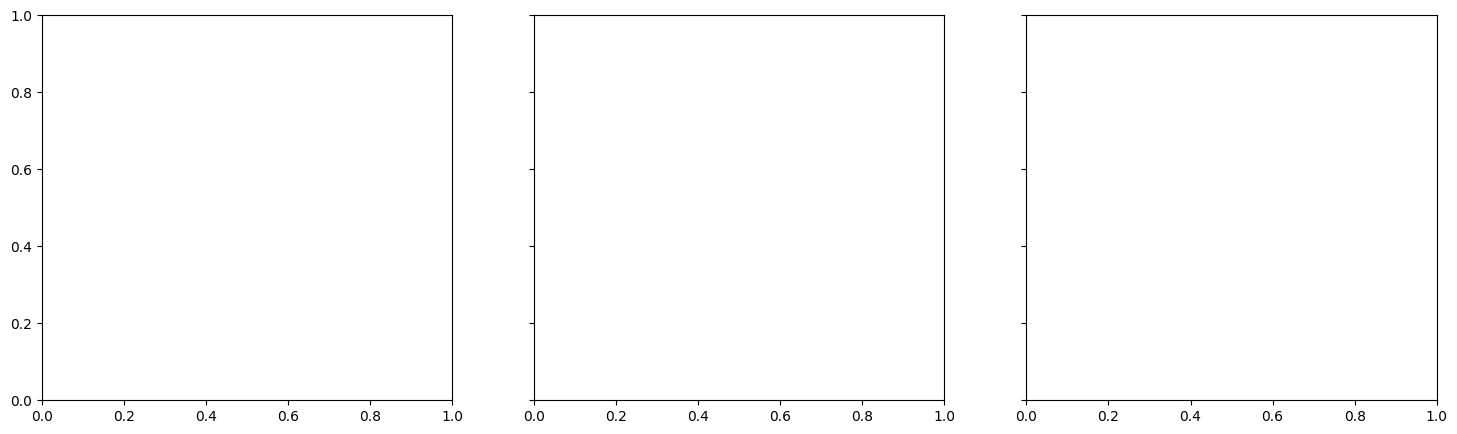

In [4]:
from scipy.signal import butter, filtfilt, medfilt

def remove_noise(signal, fs):
    """
    Удаляет высокочастотный шум с помощью низкочастотного фильтра Баттерворта.

    Фильтрация выполняется функцией `filtfilt`, поэтому фазовый сдвиг сигнала
    не вносится.

    :param signal: Исходный ЭКГ-сигнал, одномерный или многоканальный.
    :param fs: Частота дискретизации сигнала в Гц.
    :return: Отфильтрованный сигнал той же формы, что и входной.
    """

    # Магические числа из статьи
    cutoff = 50
    n = 5
    
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    
    b, a = butter(N=n, Wn=normal_cutoff, btype='low', analog=False)
    
    # Применяем фильтрацию в обе стороны (filtfilt), чтобы избежать фазового сдвига
    cleaned_signal = filtfilt(b, a, signal, axis=0)
    
    return cleaned_signal

def remove_baseline_wander(signal, fs):
    """
    Удаляет дрейф изолинии с помощью последовательного применения медианных фильтров.

    Сначала оценивается медленно меняющийся базовый тренд сигнала, затем этот
    тренд вычитается из исходного сигнала.

    :param signal: Исходный ЭКГ-сигнал, одномерный или многоканальный.
    :param fs: Частота дискретизации сигнала в Гц.
    :return: Сигнал без оцененного дрейфа изолинии.
    """
    
    # Размер окна должен быть нечетным числом для medfilt
    # Магические числа из статьи
    kernel_1 = int(0.2 * fs)
    if kernel_1 % 2 == 0: kernel_1 += 1
    
    kernel_2 = int(0.6 * fs)
    if kernel_2 % 2 == 0: kernel_2 += 1

    if signal.ndim > 1:
        # Для 2D массива задаем ядро как (длина_окна, 1)
        kernel_1 = [kernel_1, 1]
        kernel_2 = [kernel_2, 1]

    baseline_estimate = medfilt(signal, kernel_size=kernel_1)
    baseline_estimate = medfilt(baseline_estimate, kernel_size=kernel_2)
    
    # Вычитаем полученный тренд из оригинального сигнала
    detrended_signal = signal - baseline_estimate
    
    return detrended_signal

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].plot(signals[1])
axes[0].set_title("Исходный сигнал")

axes[1].plot(remove_noise(signals[1], 360))
axes[1].set_title("Без шума")

axes[2].plot(remove_baseline_wander(signals[1], 360))
axes[2].set_title("Без дрейфа изолинии")

plt.tight_layout()
plt.show()

In [7]:
# signals_filtered = []
# for s in signals:
#     s = remove_baseline_wander(s, 360)
#     s = remove_noise(s, 360)
#     signals_filtered.append(s)
# signals = np.array(signals_filtered)

In [5]:
def get_bpm(signal, annotation, start_idx, fs=360):
    """
    Рассчитывает частоту сердечных сокращений (BPM) для одного окна сигнала.

    В пределах окна подсчитываются только аннотации, соответствующие ударам сердца,
    после чего количество ударов масштабируется до значения «ударов в минуту».

    :param signal: Окно ЭКГ-сигнала, для которого считается BPM.
    :param annotation: WFDB-аннотация записи с полями `sample` и `symbol`.
    :param start_idx: Индекс начала окна в исходной записи.
    :param fs: Частота дискретизации сигнала в Гц.
    :return: Оценка BPM для указанного окна.
    """
    n_samples = signal.shape[0]
    beats_cnt = get_r_count(signal, annotation, start_idx)
    
    part_of_minute = 60 / (n_samples / fs)
    bpm = beats_cnt * part_of_minute
    return bpm

def get_r_count(signal, annotation, start_idx):
    ANNOTATION_BEAT_CODES = ['·', 'N', 'L', 'R', 'A', 'a', 'J', 'S', 'V', 'F', '!', 'e', 'j', 'E', '/', 'f', 'x', 'Q', '|']
    n_samples = signal.shape[0]
    beats_cnt = 0
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if sample < start_idx:
            continue

        if sample >= start_idx + n_samples:
            break

        if symbol in ANNOTATION_BEAT_CODES:
            beats_cnt += 1
    return beats_cnt

# 1 lead
def create_windows(signals, annotations, window_size_s=10, fs=360):
    """
    Делит записи ЭКГ на непересекающиеся окна фиксированной длины.

    Для каждого окна сохраняется фрагмент сигнала и вычисляется целевая метка —
    BPM, рассчитанный по аннотациям `atr` внутри этого окна.

    :param records: Список WFDB-записей с сигналами в `record.p_signal`.
    :param annotations: Список словарей аннотаций, соответствующих `records`.
    :param window_size_s: Длина одного окна в секундах.
    :param fs: Частота дискретизации сигнала в Гц.
    :return: Кортеж `(signals, labels)`: список окон ЭКГ и список BPM-меток.
    """
    window_size_samples = window_size_s * fs
    windowed_signals = []
    labels = []
    for signal, annotation in zip(signals, annotations):
        signal_len = signal.shape[0]
        for i in range(0, signal_len-window_size_samples, window_size_samples):
            windowed_signal = signal[i:i+window_size_samples]
            windowed_signals.append(windowed_signal)
            
            bpm = get_bpm(windowed_signal, annotation['atr'], i)
            # bpm = get_r_count(windowed_signal, annotation['atr'], i)
            labels.append(bpm)

    return windowed_signals, labels

# TODO: Для обучения делим на окна, для теста - нет
signals, labels = create_windows(signals, annotations, window_size_s=10)

print(labels[1])

NameError: name 'signals' is not defined

In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from sklearn.utils import shuffle

class BPMDataset(Dataset):
    """
    PyTorch Dataset для окон ЭКГ и соответствующих BPM-меток.

    При получении элемента сигнал нормализуется по среднему и стандартному
    отклонению, чтобы модель обучалась на сопоставимых по масштабу входах.
    """

    def __init__(self, signals, labels):
        """
        Инициализирует датасет и переводит сигналы и метки в `torch.Tensor`.

        :param signals: Список или массив окон ЭКГ формы `(N, L, C)`, где
            `N` — число окон, `L` — длина окна, `C` — число каналов.
        :param labels: Список или массив BPM-меток для каждого окна.
        """
        self.signals = np.array(signals, dtype=np.float32)
        # TODO: check
        self.labels = np.array(labels, dtype=np.float32)

    def __len__(self):
        """
        Возвращает количество окон ЭКГ в датасете.

        :return: Размер датасета.
        """
        return len(self.signals)

    def __getitem__(self, idx):
        """
        Возвращает нормализованное окно ЭКГ и соответствующую BPM-метку.

        :param idx: Индекс элемента в датасете.
        :return: Кортеж `(x, y)`, где `x` — нормализованный сигнал, а `y` —
            тензор с одним значением BPM.
        """
        x = self.signals[idx]
        y = self.labels[idx]
        return torch.tensor(x), torch.tensor([y])
    

def split_dataset(signals, labels, val_size=0.2, test_size=0.2):
    """
    Разделяет окна сигналов и BPM-метки на обучающую, валидационную и тестовую выборки.
    
    Сначала отделяется тестовая часть, затем из оставшихся данных выделяется
    валидационная часть с учетом заданной доли от общего объема данных.

    :param signals: Все окна сигналов формы `(N, L, C)`.
    :param labels: BPM-метки для всех окон.
    :param test_size: Доля тестовых данных от общего объема.
    :param val_size: Доля валидационных данных от общего объема.
    :return: Кортеж `(train_dataset, val_dataset, test_dataset)` с объектами `BPMDataset`.
    """

    # Отделяем тестовую выборку от всего объема
    train_val_sig, test_sig, train_val_lab, test_lab = train_test_split(
        signals, labels, test_size=test_size, random_state=42
    )
    
    # Поскольку берем val_size от неполной выборки, его надо пересчитать
    relative_val_size = val_size / (1.0 - test_size)
    
    train_sig, val_sig, train_lab, val_lab = train_test_split(
        train_val_sig, train_val_lab, test_size=relative_val_size, random_state=42
    )

    train_dataset = BPMDataset(train_sig, train_lab)
    val_dataset   = BPMDataset(val_sig, val_lab)
    test_dataset  = BPMDataset(test_sig, test_lab)
    
    return train_dataset, val_dataset, test_dataset


def prepare_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=32):
    """
    Создает DataLoader для обучающего, валидационного и тестового датасетов.

    Для обучающей выборки включается перемешивание, а для валидации и теста порядок
    сохраняется, чтобы метрики считались воспроизводимо.

    :param train_dataset: Обучающий датасет.
    :param val_dataset: Валидационный датасет.
    :param test_dataset: Тестовый датасет.
    :param batch_size: Размер батча для всех загрузчиков.
    :return: Кортеж `(train_loader, val_loader, test_loader)`.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader


train_dataset, val_dataset, test_dataset = split_dataset(signals, labels)
train_loader, val_loader, test_loader = prepare_dataloaders(train_dataset, val_dataset, test_dataset)


print(f"Загрузка завершена:")
print(f"Train: {len(train_dataset)} окон")
print(f"Val:   {len(val_dataset)} окон")
print(f"Test:  {len(test_dataset)} окон")

NameError: name 'signals' is not defined

# Модель

In [7]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba2 # pyright: ignore[reportMissingImports]

class MambaBPMRegressor(nn.Module):
    """
    Нейросетевая модель для регрессии BPM по окну одноканального ЭКГ-сигнала.

    Архитектура проецирует входной сигнал в пространство признаков, обрабатывает
    последовательность блоками Mamba и предсказывает одно скалярное значение BPM.
    """

    def __init__(self, d_model=64, n_layers=2):
        """
        Создает слои модели MambaBPMRegressor.

        :param d_model: Размерность скрытого пространства для Mamba-блоков.
        :param n_layers: Количество последовательно применяемых Mamba-блоков.
        """
        super().__init__()
        self.d_model = d_model
        
        # Project 1-channel ECG to d_model dimensions
        self.input_proj = nn.Linear(1, d_model)
        
        # Stack of Mamba blocks
        self.mamba_blocks = nn.ModuleList([
            Mamba2(d_model=d_model) for _ in range(n_layers)
        ])
        
        # Final regression head
        self.regression_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 16),
            nn.GELU(),
            nn.Linear(16, 1)  # Output single BPM value
        )

    def forward(self, x):
        """
        Выполняет прямой проход модели и возвращает предсказанный BPM.

        :param x: Батч окон ЭКГ формы `(batch, sequence_length, 1)`.
        :return: Тензор формы `(batch, 1)` с предсказанными значениями BPM.
        """
        x = x.unsqueeze(2)
        # x shape: (batch, sequence_length, 1)
        x = self.input_proj(x)  # -> (batch, sequence_length, d_model)
        for block in self.mamba_blocks:
            x = block(x)        # Mamba processes the sequence in its own way
        # Global average pooling over the sequence dimension
        x = x.mean(dim=1)       # -> (batch, d_model)
        return self.regression_head(x)

In [9]:
from tqdm.auto import tqdm
model = MambaBPMRegressor(d_model=32, n_layers=2).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=0.001)

best_val_loss = float('inf')
epochs_without_improvement = 0
patience = 5

epochs = 100

pbar = tqdm(range(1, epochs + 1), desc="Training Progress")

train_losses = []
val_losses = []

for epoch in pbar:
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
    
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
    train_loss = total_loss / len(train_loader.dataset)

    # Validate
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
    val_loss = total_loss / len(val_loader.dataset)

    pbar.set_postfix({
        'train_loss': f'{train_loss:.4f}',
        'val_loss': f'{val_loss:.4f}',
    })

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    # Checkpoint & early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'models/bpm_r_count.pth')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break

print(f"Training finished. Best validation MAE: {best_val_loss:.3f} BPM")

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered after 11 epochs.
Training finished. Best validation MAE: 2.235 BPM


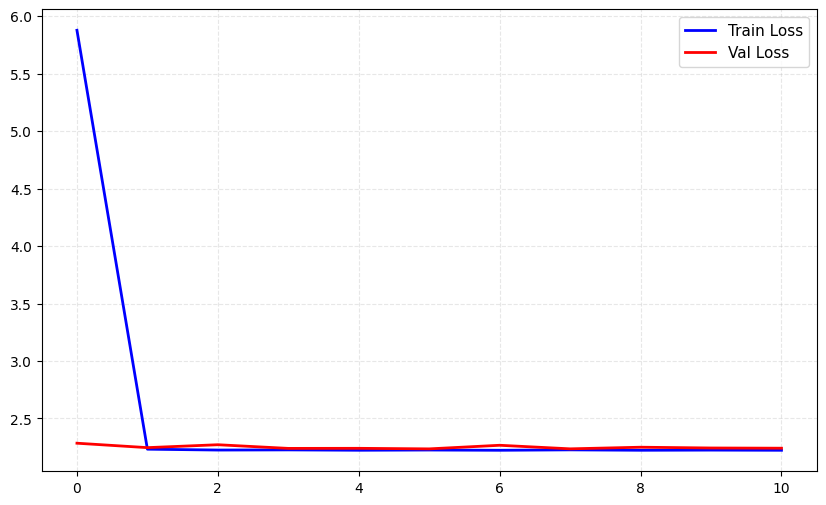

In [10]:
import matplotlib.pyplot as plt

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(val_losses, 'r-', label='Val Loss', linewidth=2)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()

# Тест

In [110]:
model = MambaBPMRegressor(d_model=32, n_layers=2)
model.load_state_dict(
        torch.load(
        r'models/bpm_preprocessed.pth'
    )
)

<All keys matched successfully>

In [11]:
model.to(device)
model.eval()

MambaBPMRegressor(
  (input_proj): Linear(in_features=1, out_features=32, bias=True)
  (mamba_blocks): ModuleList(
    (0-1): 2 x Mamba(
      (in_proj): Linear(in_features=32, out_features=128, bias=False)
      (conv1d): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(3,), groups=64)
      (act): SiLU()
      (x_proj): Linear(in_features=64, out_features=34, bias=False)
      (dt_proj): Linear(in_features=2, out_features=64, bias=True)
      (out_proj): Linear(in_features=64, out_features=32, bias=False)
    )
  )
  (regression_head): Sequential(
    (0): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

tensor([[12.1184]], device='cuda:0') tensor([10.])


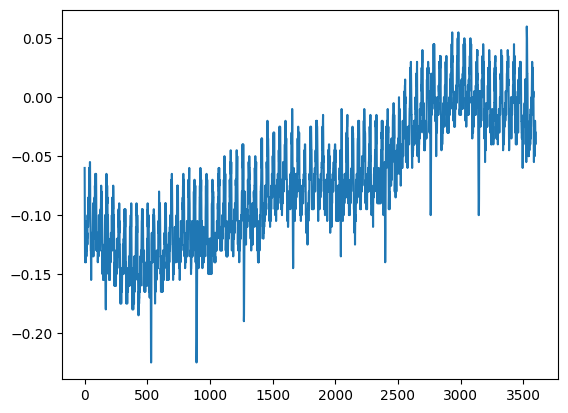

In [15]:
x, y = test_dataset[2]
plt.plot(x)

with torch.no_grad():
    x = x.unsqueeze(0).to(device)
    print(model(x), y)

In [14]:

signals, labels = create_windows(record.p_signals, annotations, 120)
min_dataset = BPMDataset(signals, labels)

x, y = min_dataset[9]
plt.plot(x)

x = x.unsqueeze(0).to(device)
print(model(x), y)

AttributeError: 'list' object has no attribute 'p_signals'

# Эксперименты

Mamba:
- Размер окна без планировщика: (5, 10, **15 - 4.3**, 20, 30)
- Размер окна с планировщиком (адаптивный шаг): (15 - 4.3, **20 - 4.2**)
- Размер окна с планировщиком (косинус): (15 - 4.2, **20 - 4.2**)

Mamba2:
- 15 - 4.4, **20 - 4.1**
- ауг: 15 - 4.1, **20 - 3**, 30 - 3.8

Загрузка завершена:
Train: 8352 окон
Val:   2784 окон
Test:  2784 окон


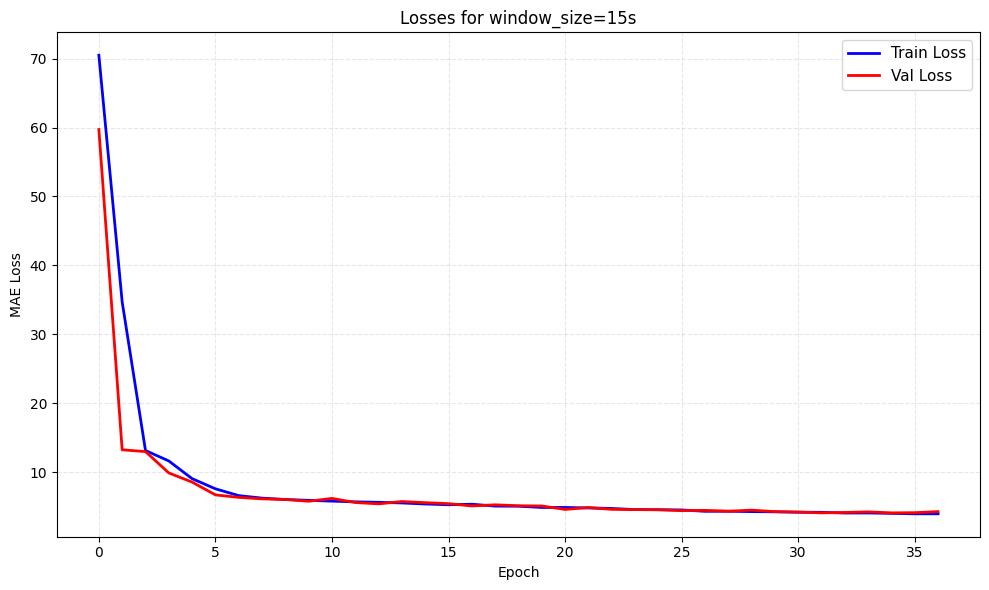

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered after 37 epochs.
Training finished. Best validation MAE: 4.092 BPM
Загрузка завершена:
Train: 6966 окон
Val:   2322 окон
Test:  2322 окон


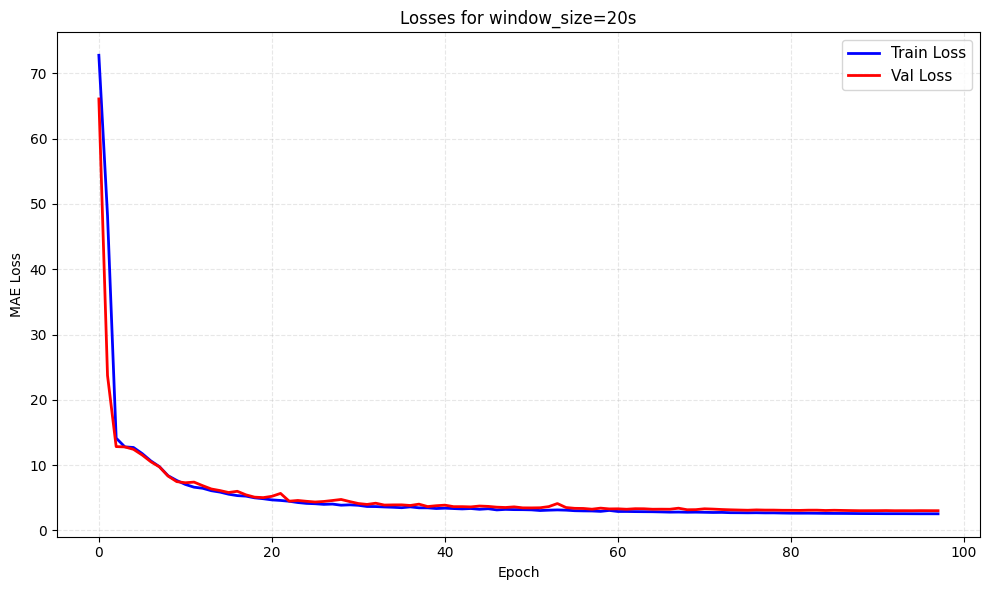

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered after 98 epochs.
Training finished. Best validation MAE: 3.026 BPM
Загрузка завершена:
Train: 4176 окон
Val:   1392 окон
Test:  1392 окон


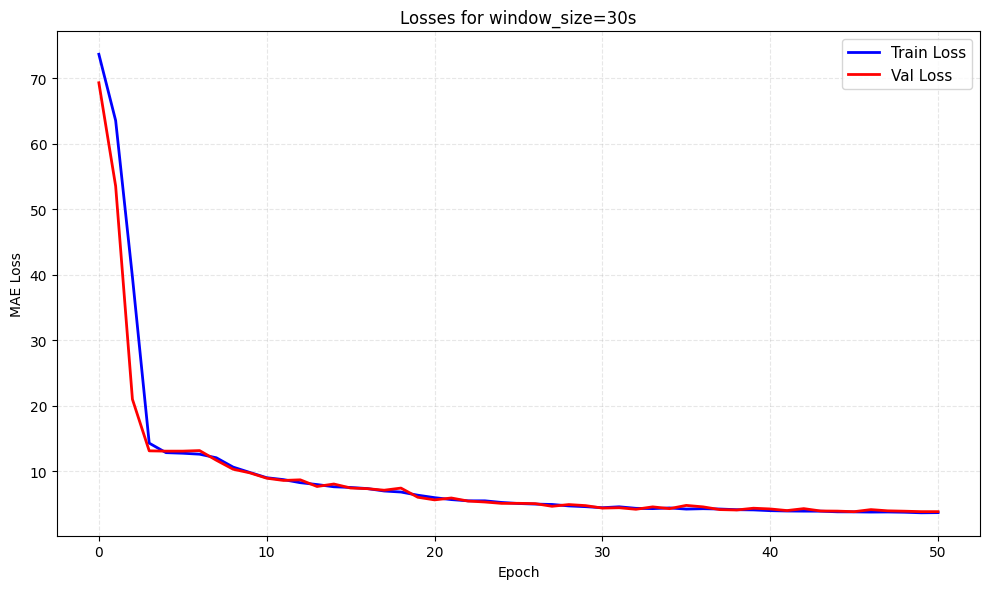

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered after 51 epochs.
Training finished. Best validation MAE: 3.837 BPM


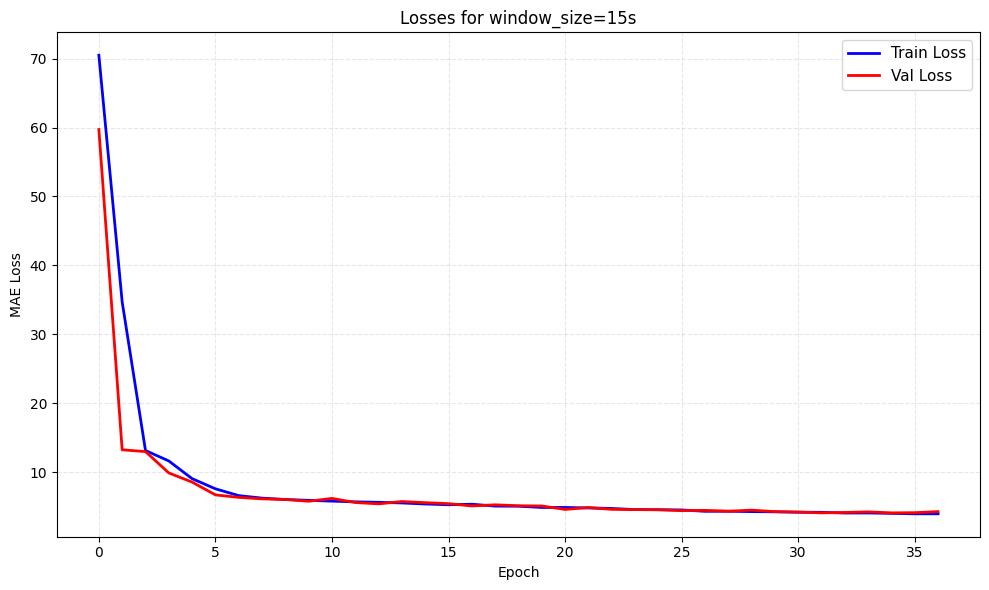

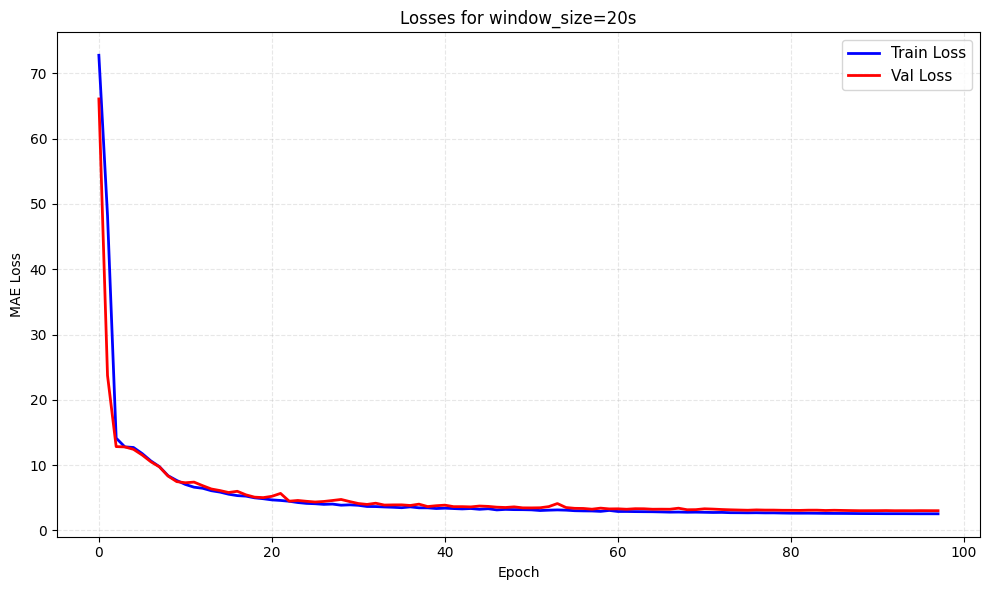

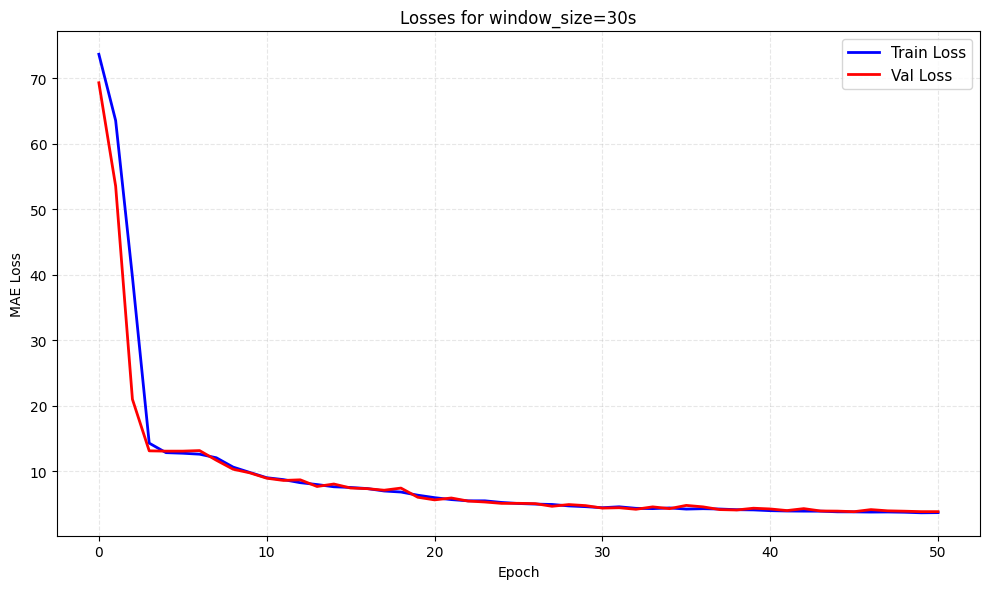

In [8]:
from tqdm.auto import tqdm
def full_pipeline(window_size, dataset_path):
    """
    Полный пайплайн обучения модели BPM по ЭКГ:
    1. Загружает WFDB-датасет.
    2. Достает одноканальные сигналы.
    3. Делит сигналы на окна заданного размера.
    4. Делит данные на train/val/test.
    5. Создает DataLoader-ы.
    6. Создает и обучает MambaBPMRegressor.
    7. Использует ReduceLROnPlateau для adaptive plateau reduction learning rate.
    8. Обновляет график losses после каждой эпохи.
    9. Сохраняет лучшую модель по validation loss.

    :param window_size: Размер окна в секундах.
    :param dataset_path: Путь к папке с WFDB-записями.
    :return: Словарь с моделью, датасетами, загрузчиками, loss-историей и лучшим val loss.
    """
    from IPython.display import display

    records, annotations = load_wfdb_dataset(dataset_path)

    signals = np.array([record.p_signal for record in records])
    signals = signals.squeeze(2)

    aug = []
    aug_annotations = []

    for s, a in zip(signals, annotations):
        odds = np.random.rand(3)

        if odds[0] > 0.5:
            aug.append(remove_baseline_wander(s, 360))
            aug_annotations.append(a)
        if odds[1] > 0.5:
            aug.append(remove_noise(s, 360))
            aug_annotations.append(a)
        if odds[2] > 0.5:
            aug.append(remove_noise(remove_baseline_wander(s, 360), 360))
            aug_annotations.append(a)

    if aug:
        aug = np.stack(aug, axis=0).astype(signals.dtype, copy=False)
        signals = np.concatenate([signals, aug], axis=0)
        annotations = annotations + aug_annotations

    windowed_signals, labels = create_windows(
        signals,
        annotations,
        window_size_s=window_size,
    )

    train_dataset, val_dataset, test_dataset = split_dataset(windowed_signals, labels)
    train_loader, val_loader, test_loader = prepare_dataloaders(
        train_dataset,
        val_dataset,
        test_dataset,
        64
    )

    print("Загрузка завершена:")
    print(f"Train: {len(train_dataset)} окон")
    print(f"Val:   {len(val_dataset)} окон")
    print(f"Test:  {len(test_dataset)} окон")

    model = MambaBPMRegressor(d_model=32, n_layers=2).to(device)
    

    criterion = nn.L1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

    best_val_loss = float("inf")
    epochs_without_improvement = 0
    patience = 5
    epochs = 100

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
        threshold=1e-4,
        min_lr=1e-5,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    train_losses = []
    val_losses = []
    learning_rates = []

    fig, ax = plt.subplots(figsize=(10, 6))
    loss_plot = display(fig, display_id=True)

    pbar = tqdm(range(1, epochs + 1), desc="Training Progress")

    for epoch in pbar:
        model.train()
        total_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                loss = criterion(pred, y)
                total_loss += loss.item() * x.size(0)

        val_loss = total_loss / len(val_loader.dataset)
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        ax.clear()
        ax.plot(train_losses, "b-", label="Train Loss", linewidth=2)
        ax.plot(val_losses, "r-", label="Val Loss", linewidth=2)
        ax.set_title(f"Losses for window_size={window_size}s")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MAE Loss")
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3, linestyle="--")
        fig.tight_layout()
        loss_plot.update(fig)

        pbar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "val_loss": f"{val_loss:.4f}",
            "lr": f"{current_lr:.2e}",
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), f"models/bpm_{window_size}s_2_aug.pth")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch} epochs.")
            break

    print(f"Training finished. Best validation MAE: {best_val_loss:.3f} BPM")

    return {
        "model": model,
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "learning_rates": learning_rates,
        "best_val_loss": best_val_loss,
    }

for window_size in [15, 20, 30]:
    full_pipeline(window_size, "physionet.org/files/mitdb/1.0.0/")